In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [2]:
def calculate_angle(a, b, c):
    """
    Calculates the angle in degrees between three points (a, b, c),
    where 'b' is the vertex.
    """
    a, b, c = np.array(a), np.array(b), np.array(c)
    ba, bc = a - b, c - b
    dot_product = np.dot(ba, bc)
    norm_ba, norm_bc = np.linalg.norm(ba), np.linalg.norm(bc)
    if norm_ba == 0 or norm_bc == 0:
        return 0.0
    cosine_angle = np.clip(dot_product / (norm_ba * norm_bc), -1.0, 1.0)
    return np.degrees(np.arccos(cosine_angle))


def add_pose_angles(df):

    df = df.copy()


    left_knee_angles, right_knee_angles = [], []
    left_hip_angles, right_hip_angles = [], []
    left_torso_angles, right_torso_angles = [], []
    left_ankle_angles, right_ankle_angles = [], []

    for _, row in df.iterrows():
        # --- Left landmarks ---
        left_shoulder = [row['LEFT_SHOULDER_x'], row['LEFT_SHOULDER_y']]
        left_hip = [row['LEFT_HIP_x'], row['LEFT_HIP_y']]
        left_knee = [row['LEFT_KNEE_x'], row['LEFT_KNEE_y']]
        left_ankle = [row['LEFT_ANKLE_x'], row['LEFT_ANKLE_y']]
        left_foot_index = [row['LEFT_FOOT_INDEX_x'], row['LEFT_FOOT_INDEX_y']]

        # --- Right landmarks ---
        right_shoulder = [row['RIGHT_SHOULDER_x'], row['RIGHT_SHOULDER_y']]
        right_hip = [row['RIGHT_HIP_x'], row['RIGHT_HIP_y']]
        right_knee = [row['RIGHT_KNEE_x'], row['RIGHT_KNEE_y']]
        right_ankle = [row['RIGHT_ANKLE_x'], row['RIGHT_ANKLE_y']]
        right_foot_index = [row['RIGHT_FOOT_INDEX_x'], row['RIGHT_FOOT_INDEX_y']]

        # --- Calculate angles ---
        left_knee_angle = calculate_angle(left_hip, left_knee, left_ankle)
        right_knee_angle = calculate_angle(right_hip, right_knee, right_ankle)
        left_hip_angle = calculate_angle(left_shoulder, left_hip, left_knee)
        right_hip_angle = calculate_angle(right_shoulder, right_hip, right_knee)

        left_hip_vertical = [left_hip[0], left_hip[1] - 1]
        right_hip_vertical = [right_hip[0], right_hip[1] - 1]
        left_torso_angle = calculate_angle(left_shoulder, left_hip, left_hip_vertical)
        right_torso_angle = calculate_angle(right_shoulder, right_hip, right_hip_vertical)

        left_ankle_angle = calculate_angle(left_knee, left_ankle, left_foot_index)
        right_ankle_angle = calculate_angle(right_knee, right_ankle, right_foot_index)

        # --- Append to lists ---
        left_knee_angles.append(left_knee_angle)
        right_knee_angles.append(right_knee_angle)
        left_hip_angles.append(left_hip_angle)
        right_hip_angles.append(right_hip_angle)
        left_torso_angles.append(left_torso_angle)
        right_torso_angles.append(right_torso_angle)
        left_ankle_angles.append(left_ankle_angle)
        right_ankle_angles.append(right_ankle_angle)

    # --- Add new columns ---
    df['left_knee_angle'] = left_knee_angles
    df['right_knee_angle'] = right_knee_angles
    df['left_hip_angle'] = left_hip_angles
    df['right_hip_angle'] = right_hip_angles
    df['left_torso_angle'] = left_torso_angles
    df['right_torso_angle'] = right_torso_angles
    df['left_ankle_angle'] = left_ankle_angles
    df['right_ankle_angle'] = right_ankle_angles

    return df

In [3]:
df = pd.read_csv(r"last_csv_all.csv")
df = add_pose_angles(df)
df = df.sort_values(by=["video_name", "frame"]).reset_index(drop=True)

df.drop(columns=['NOSE_x','NOSE_y','NOSE_visibility','LEFT_EYE_INNER_x','LEFT_EYE_INNER_y','LEFT_EYE_INNER_visibility',
                 'LEFT_EYE_x','LEFT_EYE_y','LEFT_EYE_visibility','LEFT_EYE_OUTER_x','LEFT_EYE_OUTER_y','LEFT_EYE_OUTER_visibility',
                 'RIGHT_EYE_INNER_x','RIGHT_EYE_INNER_y','RIGHT_EYE_INNER_visibility','RIGHT_EYE_x','RIGHT_EYE_y','RIGHT_EYE_visibility',
                 'RIGHT_EYE_OUTER_x','RIGHT_EYE_OUTER_y','RIGHT_EYE_OUTER_visibility','LEFT_EAR_x','LEFT_EAR_y','LEFT_EAR_visibility',
                 'RIGHT_EAR_x','RIGHT_EAR_y','RIGHT_EAR_visibility','MOUTH_LEFT_x','MOUTH_LEFT_y','MOUTH_LEFT_visibility',
                 'MOUTH_RIGHT_x','MOUTH_RIGHT_y','MOUTH_RIGHT_visibility','LEFT_ELBOW_x','LEFT_ELBOW_y','LEFT_ELBOW_visibility',
                 'RIGHT_ELBOW_x','RIGHT_ELBOW_y','RIGHT_ELBOW_visibility','LEFT_WRIST_x','LEFT_WRIST_y','LEFT_WRIST_visibility',
                 'RIGHT_WRIST_x','RIGHT_WRIST_y','RIGHT_WRIST_visibility','LEFT_PINKY_x','LEFT_PINKY_y','LEFT_PINKY_visibility',
                 'RIGHT_PINKY_x','RIGHT_PINKY_y','RIGHT_PINKY_visibility','LEFT_INDEX_x','LEFT_INDEX_y','LEFT_INDEX_visibility',
                 'RIGHT_INDEX_x','RIGHT_INDEX_y','RIGHT_INDEX_visibility','LEFT_THUMB_x','LEFT_THUMB_y','LEFT_THUMB_visibility',
                 'RIGHT_THUMB_x','RIGHT_THUMB_y','RIGHT_THUMB_visibility'], inplace=True)

meta_cols = ["frame", "video_name", "rep_counter", "phase"]
pose_cols = [c for c in df.columns if c not in meta_cols]

# Encode phase only for reference (not used for training)
label_encoder = LabelEncoder()
df["phase_label"] = label_encoder.fit_transform(df["phase"])

# Scale numeric features
scaler = StandardScaler()
df[pose_cols] = scaler.fit_transform(df[pose_cols])


In [4]:
def create_windows_for_video(data, window_size=30, stride=5):
    X = []
    for i in range(0, len(data) - window_size, stride):
        X.append(data[i:i+window_size])
    return np.array(X)

X_all = []
for _, group in df.groupby("video_name"):
    X_tmp = create_windows_for_video(group[pose_cols].values, window_size=30, stride=5)
    if len(X_tmp) > 0:  #skip empty videos
        X_all.append(X_tmp)

#Only concatenate non-empty arrays
X_all = np.concatenate(X_all, axis=0)
print(f"Size of windowed data: X={X_all.shape}")


Size of windowed data: X=(7958, 30, 44)


In [5]:
from sklearn.model_selection import train_test_split

# Train/Val/Test split
X_train, X_temp = train_test_split(X_all, test_size=0.2, random_state=42)
X_val, X_test = train_test_split(X_temp, test_size=0.5, random_state=42)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, X_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, X_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, X_test_t), batch_size=32, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [6]:
class TransformerAutoencoder(nn.Module):
    def __init__(self, num_features, seq_len, d_model=128, nhead=8, num_layers=6):
        super().__init__()
        self.seq_len = seq_len

        # Encoder
        self.input_proj = nn.Linear(num_features, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Decoder
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.output_proj = nn.Linear(d_model, num_features)

    def forward(self, x):
        z = self.input_proj(x)
        memory = self.encoder(z)
        reconstructed = self.decoder(z, memory)
        recon_out = self.output_proj(reconstructed)
        return recon_out


In [7]:
seq_len = X_train.shape[1]
num_features = X_train.shape[2]

model = TransformerAutoencoder(num_features, seq_len).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
mse_loss = nn.MSELoss()
epochs = 30


In [8]:
train_losses = []
val_losses = []
best_val_loss = float('inf') 
BEST_MODEL_PATH = "squat_transformer_autoencoder.pth"

for epoch in range(epochs):
    model.train()
    train_loss = 0
    for x_batch, _ in train_loader:
        x_batch = x_batch.to(device)
        optimizer.zero_grad()
        recon_out = model(x_batch)
        loss = mse_loss(recon_out, x_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_val, _ in val_loader:
            x_val = x_val.to(device)
            recon_out = model(x_val)
            loss = mse_loss(recon_out, x_val)
            val_loss += loss.item()

    avg_train_loss = train_loss/len(train_loader)
    avg_val_loss = val_loss/len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    
    
    # --- The Logic to Save the Best Model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"New best model saved! Val Loss: {best_val_loss:.4f}")

    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss/len(train_loader):.4f} | "
          f"Val Loss: {val_loss/len(val_loader):.4f}")

New best model saved! Val Loss: 0.0867
Epoch [1/30] | Train Loss: 0.2500 | Val Loss: 0.0867
New best model saved! Val Loss: 0.0416
Epoch [2/30] | Train Loss: 0.1027 | Val Loss: 0.0416
New best model saved! Val Loss: 0.0251
Epoch [3/30] | Train Loss: 0.0696 | Val Loss: 0.0251
New best model saved! Val Loss: 0.0176
Epoch [4/30] | Train Loss: 0.0553 | Val Loss: 0.0176
New best model saved! Val Loss: 0.0133
Epoch [5/30] | Train Loss: 0.0480 | Val Loss: 0.0133
New best model saved! Val Loss: 0.0111
Epoch [6/30] | Train Loss: 0.0429 | Val Loss: 0.0111
New best model saved! Val Loss: 0.0075
Epoch [7/30] | Train Loss: 0.0375 | Val Loss: 0.0075
New best model saved! Val Loss: 0.0067
Epoch [8/30] | Train Loss: 0.0338 | Val Loss: 0.0067
New best model saved! Val Loss: 0.0053
Epoch [9/30] | Train Loss: 0.0340 | Val Loss: 0.0053
Epoch [10/30] | Train Loss: 0.0294 | Val Loss: 0.0057
Epoch [11/30] | Train Loss: 0.0289 | Val Loss: 0.0076
New best model saved! Val Loss: 0.0045
Epoch [12/30] | Train Los

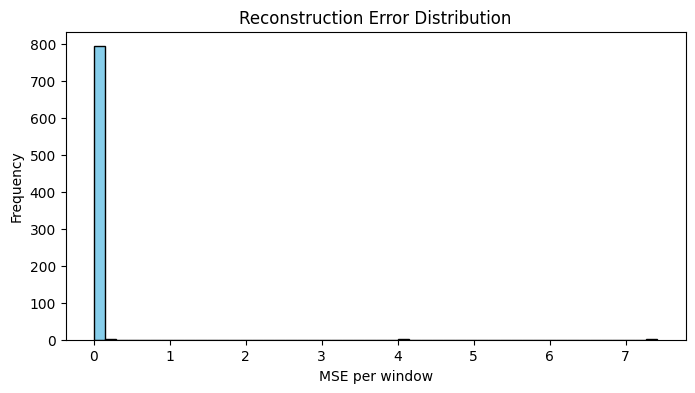

Threshold: 0.0121
Detected 40 anomalies out of 796 samples


In [9]:
model.eval()
recon_errors = []
with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(device)
        recon_out = model(x_batch)
        batch_error = torch.mean((x_batch - recon_out) ** 2, dim=(1, 2)).cpu().numpy()
        recon_errors.extend(batch_error)

recon_errors = np.array(recon_errors)

plt.figure(figsize=(8, 4))
plt.hist(recon_errors, bins=50, color='skyblue', edgecolor='black')
plt.title("Reconstruction Error Distribution")
plt.xlabel("MSE per window")
plt.ylabel("Frequency")
plt.show()

# %%
# Threshold for anomaly detection (95th percentile)
threshold = np.percentile(recon_errors, 95)
anomalies = recon_errors > threshold
print(f"Threshold: {threshold:.4f}")
print(f"Detected {np.sum(anomalies)} anomalies out of {len(recon_errors)} samples")

In [ ]:
joblib.dump(scaler, "pose_scaler.pkl")
print("Scaler saved.")

Autoencoder model and scaler saved.
